# 🔥 LSTM Sensor Anomaly — Autoencoder (Approach B, Unsupervised)

**Kapan pakai ini?** Saat lo cuma punya data **NORMAL** (kondisi ruangan biasa) dan belum punya labeled anomaly samples.
**Konsep:** Train autoencoder untuk "hafal" pattern normal → saat ada anomaly, reconstruction error melonjak.

### Spec
- **Input/Output**: 30 timesteps × 8 features
- **Features order**: `[mq135, mq2, mq3, mq4, mq5, mq7, temperature, humidity]`
- **Anomaly score**: MSE reconstruction error → normalize ke 0-1 via dynamic threshold (p95/p99 dari train errors)

### Dataset format
CSV: `timestamp, camera_id, mq135, mq2, mq3, mq4, mq5, mq7, temperature, humidity`
**No label needed.** Asumsikan SEMUA data adalah normal (atau >95% normal).
Sampling interval ~2 detik.

## 1. Setup

In [16]:
# !pip install -q tensorflow scikit-learn pandas matplotlib seaborn joblib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, RepeatVector, TimeDistributed, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- KONSTANTA ---
WINDOW_SIZE = 30
FEATURE_ORDER = ['mq135', 'mq2', 'mq3', 'mq4', 'mq5', 'mq7', 'temperature', 'humidity']
N_FEATURES = len(FEATURE_ORDER)
MODEL_OUT = '../models/lstm_anomaly.keras'
SCALER_OUT = '../models/lstm_scaler.pkl'
THRESHOLD_OUT = '../models/lstm_threshold.json'

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.21.0
GPU: False


## 2. Load Data (Normal Only)

Filter pakai data yang lo PASTI tau itu normal:
- Periode dari log ESP32 yang nggak ada incident
- Bisa cek log status=="Aman" dari WebSocket history lo

In [17]:
DATA_PATH = '../data/sensor_logs_normal.csv'
USE_REAL = os.path.exists(DATA_PATH)

if USE_REAL:
    df = pd.read_csv(DATA_PATH)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values(['camera_id', 'timestamp']).reset_index(drop=True)
    print(f'✅ Loaded {len(df):,} normal samples')
else:
    # Synthetic untuk smoke test
    print('⚠️  Generating synthetic NORMAL data...')
    rng = np.random.default_rng(SEED)
    n = 12000
    base = {'mq135': 800, 'mq2': 600, 'mq3': 400, 'mq4': 700, 'mq5': 650,
            'mq7': 500, 'temperature': 28.0, 'humidity': 65.0}
    noise = {'mq135': 50, 'mq2': 40, 'mq3': 30, 'mq4': 50, 'mq5': 45,
             'mq7': 35, 'temperature': 0.5, 'humidity': 2.0}
    data = {'camera_id': ['synth_01'] * n,
            'timestamp': pd.date_range('2025-01-01', periods=n, freq='2s')}
    for k, b in base.items():
        # Slow sinusoidal drift + gaussian noise
        drift = 0.3 * noise[k] * np.sin(np.arange(n) * 0.001)
        data[k] = b + drift + rng.normal(0, noise[k], n)
    df = pd.DataFrame(data)
    # Clamp
    for k in ['mq135', 'mq2', 'mq3', 'mq4', 'mq5', 'mq7']:
        df[k] = df[k].clip(0, 4095).round(2)
    df['temperature'] = df['temperature'].clip(-10, 80).round(2)
    df['humidity'] = df['humidity'].clip(0, 100).round(2)
    print(f'✅ Generated {len(df):,} synthetic normal samples')

df.head()

⚠️  Generating synthetic NORMAL data...
✅ Generated 12,000 synthetic normal samples


,camera_id,timestamp,mq135,mq2,mq3,mq4,mq5,mq7,temperature,humidity
0,synth_01,2025-01-01 00:00:00,815.24,587.61,387.33,701.21,640.64,527.39,27.52,65.04
1,synth_01,2025-01-01 00:00:02,748.02,602.42,429.10,729.36,654.79,489.12,27.55,66.82
2,synth_01,2025-01-01 00:00:04,837.55,550.39,387.04,700.84,638.96,553.49,28.26,65.88
3,synth_01,2025-01-01 00:00:06,847.07,544.53,410.68,690.93,636.38,464.71,28.37,65.06
4,synth_01,2025-01-01 00:00:08,702.51,607.34,396.27,701.43,612.56,441.21,28.87,66.48


## 3. Window Generation

In [18]:
def make_windows(df, window_size=WINDOW_SIZE, stride=3):
    """Stride kecil = lebih banyak overlap = lebih banyak data buat autoencoder."""
    X_list = []
    for cam_id, group in df.groupby('camera_id'):
        feat = group[FEATURE_ORDER].values
        if len(feat) < window_size:
            continue
        for i in range(0, len(feat) - window_size + 1, stride):
            X_list.append(feat[i:i+window_size])
    return np.array(X_list, dtype=np.float32)

X = make_windows(df)
print(f'X shape: {X.shape}')

X shape: (3991, 30, 8)


## 4. Normalization + Split

Split: 70% train, 15% val, 15% test (semua normal). Lo bisa juga inject sedikit anomaly buat validasi threshold.

In [19]:
X_train, X_temp = train_test_split(X, test_size=0.3, random_state=SEED)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=SEED)

scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, N_FEATURES))

def scale(arr):
    shape = arr.shape
    return scaler.transform(arr.reshape(-1, N_FEATURES)).reshape(shape).astype(np.float32)

Xtr, Xv, Xte = scale(X_train), scale(X_val), scale(X_test)
print(f'Train {Xtr.shape} | Val {Xv.shape} | Test {Xte.shape}')

Train (2793, 30, 8) | Val (599, 30, 8) | Test (599, 30, 8)


## 5. LSTM Autoencoder Architecture

**Encoder-Decoder design:**
```
Input (30, 8) → LSTM(64) → LSTM(16, latent)
                                    ↓
Output (30, 8) ← TimeDist(Dense(8)) ← LSTM(64, return_seq=True) ← LSTM(16, return_seq=True) ← RepeatVector(30)
```
Bottleneck di 16 unit latent space — model dipaksa kompres pattern normal.

In [20]:
def build_autoencoder():
    inp = Input(shape=(WINDOW_SIZE, N_FEATURES))
    # Encoder
    x = LSTM(64, return_sequences=True, dropout=0.1)(inp)
    x = BatchNormalization()(x)
    x = LSTM(16, return_sequences=False, dropout=0.1)(x)  # latent
    # Decoder
    x = RepeatVector(WINDOW_SIZE)(x)
    x = LSTM(16, return_sequences=True, dropout=0.1)(x)
    x = LSTM(64, return_sequences=True, dropout=0.1)(x)
    out = TimeDistributed(Dense(N_FEATURES))(x)
    
    model = Model(inp, out, name='lstm_autoencoder')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return model

ae = build_autoencoder()
ae.summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 30, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 30, 64)              │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 30, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 16)                  │           5,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector_1 (RepeatVector)       │ (None, 30, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 30, 16)              │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 30, 64)              │          20,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 30, 8)               │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,496 (185.53 KB)

 Trainable params: 47,368 (185.03 KB)

 Non-trainable params: 128 (512.00 B)

## 6. Training

In [21]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
]

# Target = input itself (reconstruct)
history = ae.fit(
    Xtr, Xtr,
    validation_data=(Xv, Xv),
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 0.9676 - mae: 0.7833 - val_loss: 0.9608 - val_mae: 0.7805 - learning_rate: 0.0010
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.9527 - mae: 0.7774 - val_loss: 0.9512 - val_mae: 0.7766 - learning_rate: 0.0010
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.9486 - mae: 0.7757 - val_loss: 0.9415 - val_mae: 0.7727 - learning_rate: 0.0010
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.9460 - mae: 0.7746 - val_loss: 0.9387 - val_mae: 0.7715 - learning_rate: 0.0010
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.9446 - mae: 0.7741 - val_loss: 0.9346 - val_mae: 0.7699 - learning_rate: 0.0010
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.9429 - mae: 0.7733 - val_loss: 0.9322 - val_mae: 0.7691 - learning_rate: 0.0010
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.9419 - mae: 0.7729 - val_loss: 0.9306 - val_mae: 0.7683 - learning_rate: 0.0010
Epoch 8/60
44

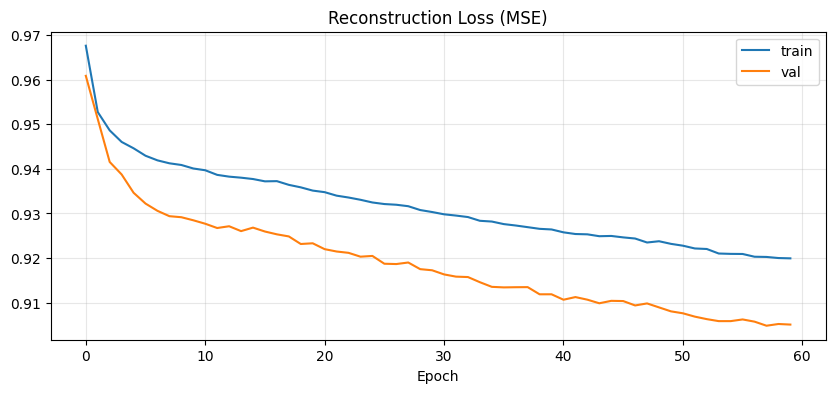

In [22]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Reconstruction Loss (MSE)'); plt.xlabel('Epoch'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 7. Compute Anomaly Threshold

Reconstruction error pada **normal test set** → pakai percentile (p95/p99) sebagai threshold.
Score di atas ini = anomaly.

Normal test errors: mean=0.90693, std=0.08165
                    p50=0.90142
                    p95=1.04826
                    p99=1.10195
                    max=1.12737

🎯 Threshold (raw MSE): 1.10195


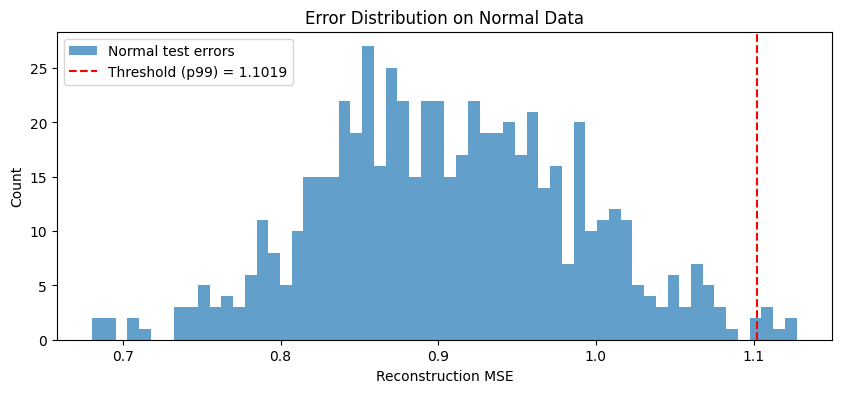

In [23]:
def reconstruction_error(model, X):
    """MSE per window."""
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=(1, 2))

errors_test = reconstruction_error(ae, Xte)
print(f'Normal test errors: mean={errors_test.mean():.5f}, std={errors_test.std():.5f}')
print(f'                    p50={np.percentile(errors_test, 50):.5f}')
print(f'                    p95={np.percentile(errors_test, 95):.5f}')
print(f'                    p99={np.percentile(errors_test, 99):.5f}')
print(f'                    max={errors_test.max():.5f}')

# Pakai p99 sebagai threshold default — 1% false positive rate di normal data
threshold_raw = float(np.percentile(errors_test, 99))
print(f'\n🎯 Threshold (raw MSE): {threshold_raw:.5f}')

plt.figure(figsize=(10, 4))
plt.hist(errors_test, bins=60, alpha=0.7, label='Normal test errors')
plt.axvline(threshold_raw, color='red', linestyle='--', label=f'Threshold (p99) = {threshold_raw:.4f}')
plt.xlabel('Reconstruction MSE'); plt.ylabel('Count'); plt.title('Error Distribution on Normal Data'); plt.legend()
plt.show()

## 8. Inject Synthetic Anomaly untuk Validasi

Test: kasih input yang spike kayak kebakaran, check error-nya melonjak.

Normal errors:  mean=0.90693, max=1.12737
Anomaly errors: mean=3.42207, min=1.91160

Detection rate (recall): 200/200 = 100.0%
False positive rate:    6/599 = 1.0%


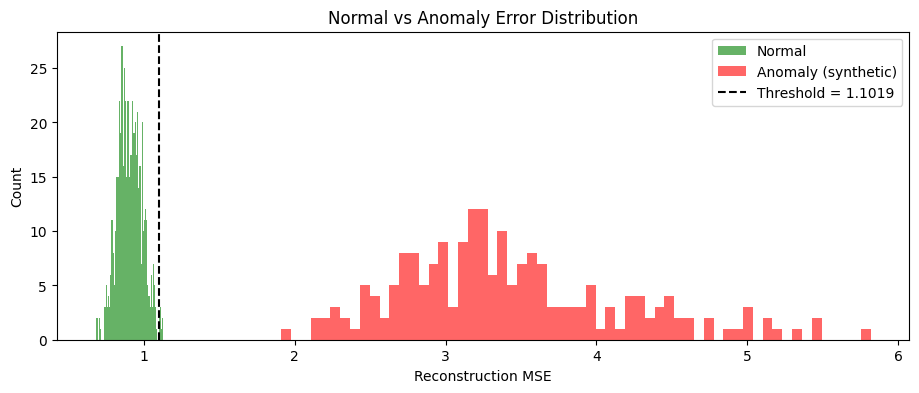

In [24]:
rng = np.random.default_rng(SEED)

def inject_anomaly(X_normal, n_samples=200):
    """Tambah spike pattern ke window normal (di-scale)."""
    idx = rng.choice(len(X_normal), n_samples, replace=False)
    anom = X_normal[idx].copy()
    for i in range(n_samples):
        start = rng.integers(5, 15)
        # Spike di 6 sensor MQ (feature 0-5)
        for f in range(6):
            spike = rng.uniform(2.5, 5.0)  # 2.5-5 std deviations
            ramp = np.linspace(0, spike, WINDOW_SIZE - start)
            anom[i, start:, f] += ramp
        # Temperature naik (feature 6)
        anom[i, start:, 6] += rng.uniform(2.0, 4.0)
    return anom

Xte_anom = inject_anomaly(Xte)
errors_anom = reconstruction_error(ae, Xte_anom)

print(f'Normal errors:  mean={errors_test.mean():.5f}, max={errors_test.max():.5f}')
print(f'Anomaly errors: mean={errors_anom.mean():.5f}, min={errors_anom.min():.5f}')

# Detection rate
tp = (errors_anom >= threshold_raw).sum()
fp = (errors_test >= threshold_raw).sum()
print(f'\nDetection rate (recall): {tp}/{len(errors_anom)} = {tp/len(errors_anom)*100:.1f}%')
print(f'False positive rate:    {fp}/{len(errors_test)} = {fp/len(errors_test)*100:.1f}%')

plt.figure(figsize=(11, 4))
plt.hist(errors_test, bins=60, alpha=0.6, label='Normal', color='green')
plt.hist(errors_anom, bins=60, alpha=0.6, label='Anomaly (synthetic)', color='red')
plt.axvline(threshold_raw, color='black', linestyle='--', label=f'Threshold = {threshold_raw:.4f}')
plt.xlabel('Reconstruction MSE'); plt.ylabel('Count'); plt.title('Normal vs Anomaly Error Distribution'); plt.legend()
plt.show()

## 9. Wrap Model: Output Normalized Anomaly Score (0-1)

Supaya inference di `app/lstm_anomaly.py` cukup `predict()` tanpa hitung MSE manual, gw bungkus autoencoder dalam **wrapper model** yang langsung output anomaly score 0-1 (sigmoid-like normalization).

In [28]:
# === SECTION 9: Sanity Check Manual (No Lambda Wrapper) ===
# Compute anomaly score in pure numpy — exact logic yang bakal dipake di app/lstm_anomaly.py

SCALE_K = 1.0 / max(threshold_raw, 1e-6) * 5.0
print(f'SCALE_K: {SCALE_K:.4f}')
print(f'Threshold MSE: {threshold_raw:.5f}')

def compute_anomaly_score(model, windows_scaled):
    """Replicate logic untuk inference. NumPy only setelah model.predict()."""
    recon = model.predict(windows_scaled, verbose=0)
    mse = np.mean(np.square(windows_scaled - recon), axis=(1, 2))
    # Sigmoid normalize ke 0-1
    score = 1.0 / (1.0 + np.exp(-SCALE_K * (mse - threshold_raw)))
    return score

# Smoke test
s_normal = compute_anomaly_score(ae, Xte[:50])
s_anom = compute_anomaly_score(ae, Xte_anom[:50])
print(f'\nNormal scores:  mean={s_normal.mean():.3f}, max={s_normal.max():.3f}')
print(f'Anomaly scores: mean={s_anom.mean():.3f}, min={s_anom.min():.3f}')

SCALE_K: 4.5374
Threshold MSE: 1.10195

Normal scores:  mean=0.285, max=0.479
Anomaly scores: mean=0.999, min=0.975


## 10. Save Wrapper Model + Scaler

In [29]:
# === SECTION 10: Save Autoencoder + Scaler + Metadata ===
import json

os.makedirs(os.path.dirname(MODEL_OUT), exist_ok=True)

# Save AUTOENCODER MENTAH (bukan wrapper). Pure Keras model, no Lambda.
ae.save(MODEL_OUT)
joblib.dump(scaler, SCALER_OUT)

# Save threshold + scale_k ke JSON — dibaca app/lstm_anomaly.py saat startup
meta = {
    'approach': 'autoencoder_raw',
    'threshold_mse_raw': float(threshold_raw),
    'scale_k': float(SCALE_K),
    'window_size': WINDOW_SIZE,
    'features': FEATURE_ORDER,
    'anomaly_threshold_normalized': 0.5,
    'note': 'app/lstm_anomaly.py hitung MSE + sigmoid normalization manual via NumPy',
}
with open(THRESHOLD_OUT, 'w') as f:
    json.dump(meta, f, indent=2)

size_mb = os.path.getsize(MODEL_OUT) / 1024**2
print(f'✅ Model:    {MODEL_OUT} ({size_mb:.2f} MB)')
print(f'✅ Scaler:   {SCALER_OUT}')
print(f'✅ Metadata: {THRESHOLD_OUT}')
print(f'\n📌 3 file ini WAJIB ada di folder models/ project lo')

✅ Model:    ../models/lstm_anomaly.keras (0.60 MB)
✅ Scaler:   ../models/lstm_scaler.pkl
✅ Metadata: ../models/lstm_threshold.json

📌 3 file ini WAJIB ada di folder models/ project lo


## 11. Smoke Test

In [30]:
# === SECTION 11: Smoke Test — Reload & Predict ===
from tensorflow.keras.models import load_model

# safe_mode=True (default) — autoencoder mentah, no Lambda, no risk
reloaded = load_model(MODEL_OUT, compile=False)
reloaded_scaler = joblib.load(SCALER_OUT)

with open(THRESHOLD_OUT) as f:
    meta = json.load(f)
threshold_loaded = meta['threshold_mse_raw']
scale_k_loaded = meta['scale_k']

def score_window(model, scaler, raw_window):
    """Exact replica logic untuk inference di backend."""
    scaled = scaler.transform(
        raw_window.reshape(-1, N_FEATURES)
    ).reshape(raw_window.shape).astype(np.float32)
    
    recon = model.predict(scaled, verbose=0)
    mse = float(np.mean(np.square(scaled - recon)))
    # Sigmoid normalization → 0-1
    score = 1.0 / (1.0 + np.exp(-scale_k_loaded * (mse - threshold_loaded)))
    return float(score), mse

# Test: normal sample
raw_normal = X_test[0:1]
score_n, mse_n = score_window(reloaded, reloaded_scaler, raw_normal)
print(f'Normal sample → MSE: {mse_n:.5f}, anomaly score: {score_n:.4f}')

# Test: synthetic anomaly (pakai inject_anomaly dari section sebelumnya)
# Build raw anomaly: baseline + spike
baseline_raw = np.tile(
    np.array([800, 600, 400, 700, 650, 500, 28, 65], dtype=np.float32),
    (1, WINDOW_SIZE, 1)
).reshape(1, WINDOW_SIZE, N_FEATURES)
baseline_scaled = scaler.transform(baseline_raw.reshape(-1, N_FEATURES)).reshape(baseline_raw.shape).astype(np.float32)
anom_scaled = inject_anomaly(baseline_scaled, 1)
# Reverse scaling untuk dapet "raw" equivalent (cuma buat test pipeline end-to-end)
raw_anom_test = scaler.inverse_transform(anom_scaled.reshape(-1, N_FEATURES)).reshape(anom_scaled.shape)
score_a, mse_a = score_window(reloaded, reloaded_scaler, raw_anom_test)
print(f'Anomaly sample → MSE: {mse_a:.5f}, anomaly score: {score_a:.4f}')

print('\n✅ Done!')
print('📂 Pindahin 3 file ini ke folder models/ di project lo:')
print(f'   {MODEL_OUT}')
print(f'   {SCALER_OUT}')
print(f'   {THRESHOLD_OUT}')

Normal sample → MSE: 0.80946, anomaly score: 0.2096
Anomaly sample → MSE: 3.14497, anomaly score: 0.9999

✅ Done!
📂 Pindahin 3 file ini ke folder models/ di project lo:
   ../models/lstm_anomaly.keras
   ../models/lstm_scaler.pkl
   ../models/lstm_threshold.json


## 12. Patch `app/lstm_anomaly.py` untuk Autoencoder

Karena wrapper-nya udah langsung output score 0-1, patch-nya simpel — cuma perlu load scaler.

```python
# Di app/lstm_anomaly.py

import joblib

LSTM_SCALER_PATH = os.getenv('LSTM_SCALER_PATH', 'models/lstm_scaler.pkl')
_lstm_scaler = None
ANOMALY_THRESHOLD = 0.5  # wrapper sudah normalize 0-1

def load_lstm_model():
    global _lstm_model, _lstm_scaler
    if not os.path.exists(LSTM_MODEL_PATH):
        print(f'[LSTM] Model tidak ditemukan: {LSTM_MODEL_PATH}')
        return
    try:
        from tensorflow.keras.models import load_model
        # safe_mode=False karena wrapper pakai Lambda layer
        _lstm_model = load_model(LSTM_MODEL_PATH, compile=False, safe_mode=False)
        print(f'[LSTM] Model loaded: {LSTM_MODEL_PATH}')
        if os.path.exists(LSTM_SCALER_PATH):
            _lstm_scaler = joblib.load(LSTM_SCALER_PATH)
            print(f'[LSTM] Scaler loaded: {LSTM_SCALER_PATH}')
    except Exception as e:
        print(f'[LSTM] Gagal load: {e}')


def predict_anomaly(camera_id: str) -> dict:
    with _buffer_lock:
        buf = _buffers.get(camera_id)
        if not buf or len(buf) < WINDOW_SIZE:
            return {'available': False, 'anomaly_score': 0.0, 'is_anomaly': False,
                    'samples_used': len(buf) if buf else 0,
                    'reason': f'butuh {WINDOW_SIZE} samples, baru {len(buf) if buf else 0}'}
        window = np.array(list(buf), dtype=np.float32)

    if _lstm_model is None:
        return {'available': False, 'anomaly_score': 0.0, 'is_anomaly': False,
                'samples_used': WINDOW_SIZE, 'reason': 'LSTM model belum dimuat'}

    try:
        # APPLY SCALER (penting!)
        if _lstm_scaler is not None:
            flat = window.reshape(-1, len(FEATURE_ORDER))
            window = _lstm_scaler.transform(flat).reshape(window.shape).astype(np.float32)
        x = window[np.newaxis, ...]
        score = float(_lstm_model.predict(x, verbose=0).flatten()[0])
        return {'available': True, 'anomaly_score': round(score, 4),
                'is_anomaly': score >= ANOMALY_THRESHOLD,
                'samples_used': WINDOW_SIZE, 'reason': 'ok'}
    except Exception as e:
        return {'available': False, 'anomaly_score': 0.0, 'is_anomaly': False,
                'samples_used': WINDOW_SIZE, 'reason': f'inference error: {e}'}
```

## 13. Logging Data Asli untuk Re-Training Nanti

Biar bisa ganti synthetic ke real data, lo bisa tambah endpoint logger di `app/sensor.py`. Tinggal append tiap sensor data ke CSV harian:

```python
# Di app/sensor.py, dalam receive_sensor_data()
import csv
from pathlib import Path

LOG_DIR = Path('data/sensor_logs')
LOG_DIR.mkdir(parents=True, exist_ok=True)

def _log_to_csv(camera_id, data):
    fname = LOG_DIR / f'{datetime.now().strftime("%Y%m%d")}.csv'
    write_header = not fname.exists()
    with open(fname, 'a', newline='') as f:
        w = csv.writer(f)
        if write_header:
            w.writerow(['timestamp', 'camera_id'] + FEATURE_ORDER)
        w.writerow([data['timestamp'], camera_id] + [data.get(k, 0) for k in FEATURE_ORDER])

# Di akhir receive_sensor_data() sebelum return:
_log_to_csv(payload.camera_id, data)
```

Setelah 1-2 minggu kumpulin data, retrain pakai notebook ini dengan `DATA_PATH` yang mengarah ke log CSV gabungan.